# Task 1: NAV Trend Analysis

## Objective
Visualize the daily NAV movement of all mutual fund schemes between 2022 and 2025. The chart highlights major market phases such as the 2023 bull run and the 2024 market correction.

In [172]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [173]:
conn = sqlite3.connect("../bluestock_mf.db")

In [174]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,dim_fund
1,dim_date
2,sqlite_sequence
3,fact_nav
4,fact_transactions
5,fact_performance
6,fact_aum
7,fact_sip_inflows
8,fact_category_inflows
9,fact_folio_count


In [175]:
nav = pd.read_sql("SELECT * FROM fact_nav", conn)

aum = pd.read_sql("SELECT * FROM fact_aum", conn)

sip = pd.read_sql("SELECT * FROM fact_sip_inflows", conn)

investor = pd.read_sql("SELECT * FROM fact_transactions", conn)

geo = pd.read_sql("SELECT * FROM fact_category_inflows", conn)

folio = pd.read_sql("SELECT * FROM fact_folio_count", conn)

portfolio = pd.read_sql("SELECT * FROM fact_portfolio_holdings", conn)

In [176]:
nav.head()

nav.info()

nav.describe()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   nav_id     46000 non-null  int64  
 1   amfi_code  46000 non-null  int64  
 2   date_id    46000 non-null  int64  
 3   nav        46000 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 1.4 MB


,nav_id,amfi_code,date_id,nav
count,46000.000000,46000.000000,46000.000000,46000.000000
mean,23000.500000,120247.000000,638.223478,269.570265
std,13279.200528,14352.317221,391.694887,577.187060
min,1.000000,100016.000000,2.000000,26.136600
25%,11500.750000,118632.750000,295.000000,69.170425
50%,23000.500000,119551.500000,604.500000,122.732150
75%,34500.250000,120842.250000,1001.000000,260.338675
max,46000.000000,149324.000000,1306.000000,4268.549700


In [177]:
print(nav.columns)
print(sip.columns)

Index(['nav_id', 'amfi_code', 'date_id', 'nav'], dtype='str')
Index(['sip_id', 'date_id', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [178]:
nav["date_id"] = pd.to_datetime(nav["date_id"])

sip["date_id"] = pd.to_datetime(sip["date_id"])

In [179]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

print(pd.read_sql(query, conn))

                       name
0                  dim_fund
1                  dim_date
2           sqlite_sequence
3                  fact_nav
4         fact_transactions
5          fact_performance
6                  fact_aum
7          fact_sip_inflows
8     fact_category_inflows
9          fact_folio_count
10  fact_portfolio_holdings
11   fact_benchmark_indices


In [180]:
date_dim = pd.read_sql("SELECT * FROM dim_date", conn)
print(date_dim.head())

   date_id            full_date  year  month  quarter
0        1  2022-01-01 00:00:00  2022      1        1
1        2  2022-01-02 00:00:00  2022      1        1
2        3  2022-01-03 00:00:00  2022      1        1
3        4  2022-01-04 00:00:00  2022      1        1
4        5  2022-01-05 00:00:00  2022      1        1


In [181]:
import pandas as pd
import plotly.express as px
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    title="Daily NAV Trend"
)
fig.show()

In [182]:
fig.write_image("../charts/daily_nav_trend.png")

### Insight 1: NAV Trend Analysis

The daily NAV of mutual fund schemes showed an overall upward trend from 2022 to 2026, reflecting long-term growth despite periods of market volatility.
**Supporting Chart:** Daily NAV Trend

# Task-2 : AUM growth bar chart

## Objective
AUM growth bar chart — grouped bar by fund house for each year 2022–2025. Highlight SBI at ₹12.5L Cr dominance using Seaborn.

In [183]:
import pandas as pd 
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")


In [184]:
aum.head()



,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [185]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

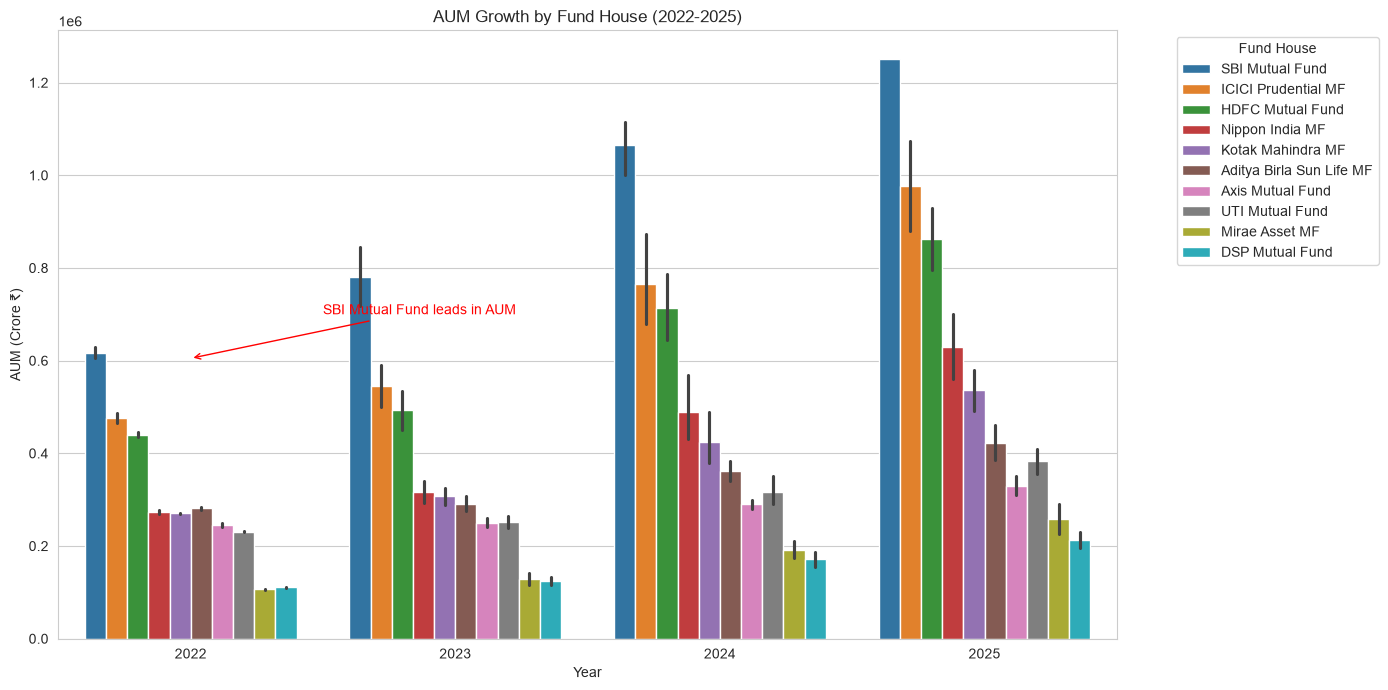

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)
plt.annotate(
    "SBI Mutual Fund leads in AUM",
    xy=(0, 605000),          # Adjust if needed
    xytext=(0.5, 700000),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=10
)
plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore ₹)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.savefig("../charts/aum_growth_by_fund_house.png", dpi=300)
plt.show()

### Insight 2: AUM Growth

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, demonstrating strong investor confidence and market leadership.
**Supporting Chart:** AUM Growth by Fund House (2022–2025)

# Task-3 : SIP inflow time-series

## Objective
 monthly SIP trend Jan 2022 – Dec 2025. Annotate the ₹31,002 Cr all-time high (Dec 2025) using Plotly.

In [187]:
import pandas as pd
import plotly.express as px
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

In [188]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [189]:
fig = px.line(
    sip, 
    x="month", 
    y="sip_inflow_crore", 
    title = "Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True
)
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (All-Time High)",
    showarrow=True,
    arrowhead=2,
    ax=-50,
    ay=-50,
    font=dict(color="red", size=12)
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)
fig.show()
fig.write_image("../charts/sip_inflow_trend.png")


### Insight 3: SIP Inflow Trend

Monthly SIP inflows increased consistently and reached an all-time high of **₹31,002 crore** in **December 2025**, indicating growing retail participation in mutual funds.
**Supporting Chart:** Monthly SIP Inflow Trend

# Task4 : Category inflow heatmap

## Objective
months on X-axis, fund categories on Y-axis, net inflow as colour intensity using Seaborn.

In [190]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

In [191]:
cat.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [192]:
cat["month"] = pd.to_datetime(cat["month"])

cat["month"] = cat["month"].dt.strftime("%b-%Y")

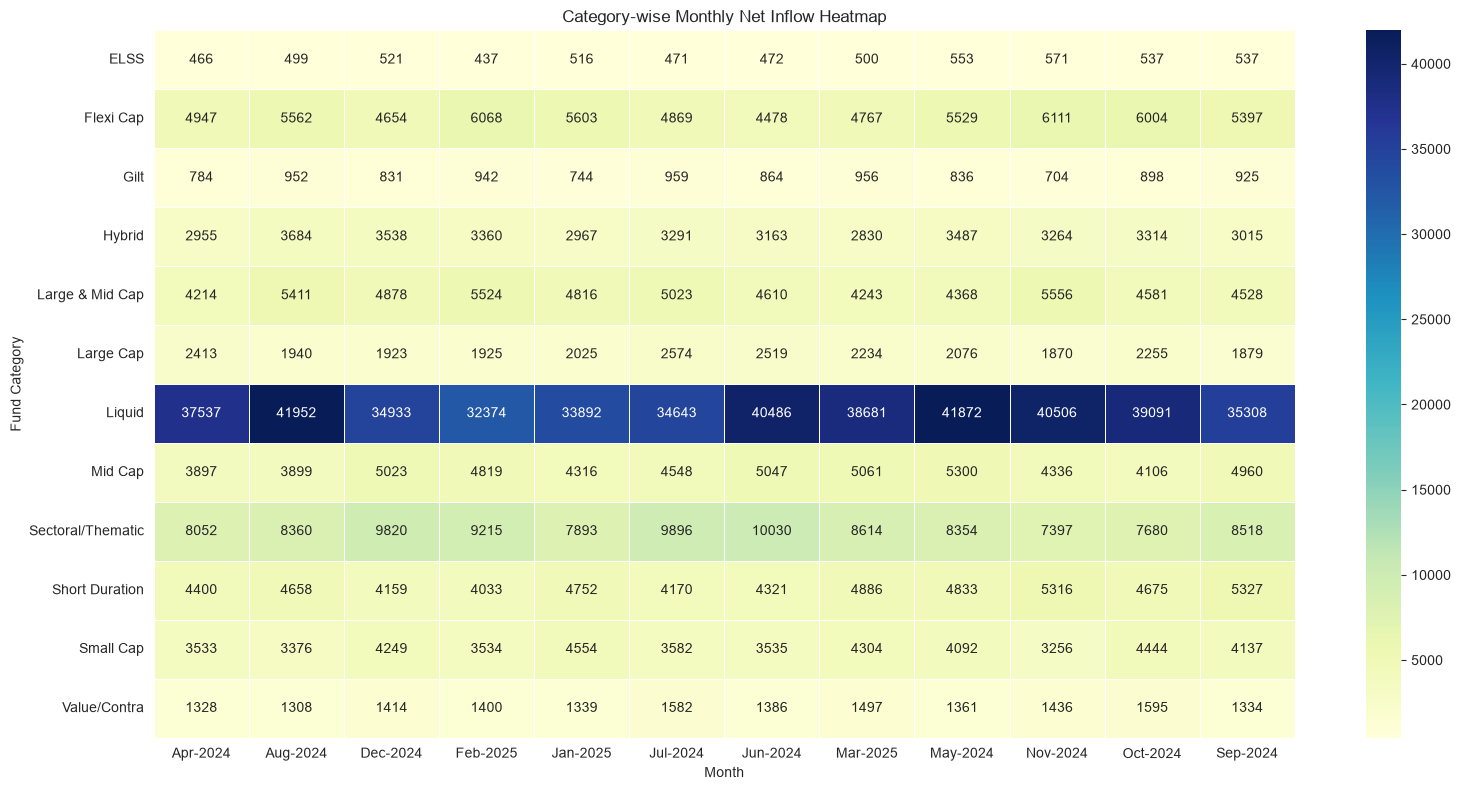

In [193]:
heatmap_data = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.savefig("../charts/category_inflow_heatmap.png")
plt.show()

### Insight 4: Category-wise Inflows

Different mutual fund categories attracted varying levels of investor interest over time, with some categories showing consistently higher net inflows than others.
**Supporting Chart:** Category Inflow Heatmap

# Task-5: Investor demographics

## Objective
Investor demographics — age group distribution pie chart. SIP amount box plot by age group. Gender split

In [194]:
import pandas as pd
investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

In [195]:
investor.head()
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

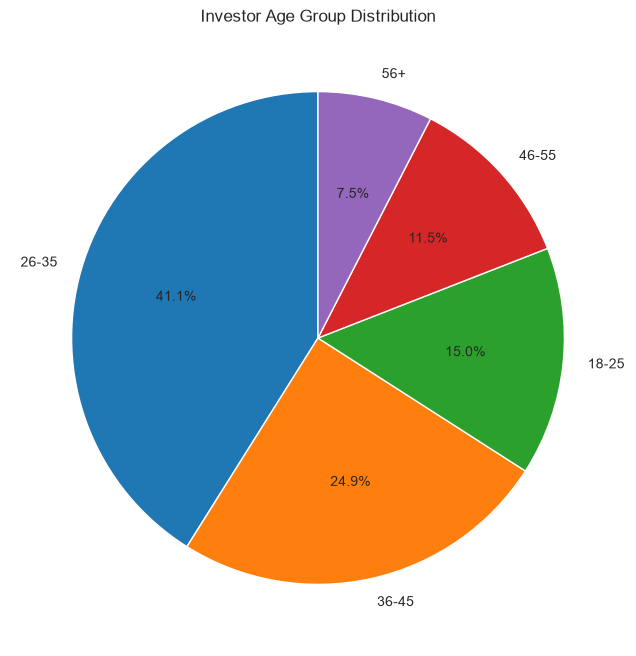

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig("../charts/age_group_distribution.png", dpi=300)

plt.show()

### Insight

The age group distribution shows which age segment contributes the highest number of mutual fund investors.

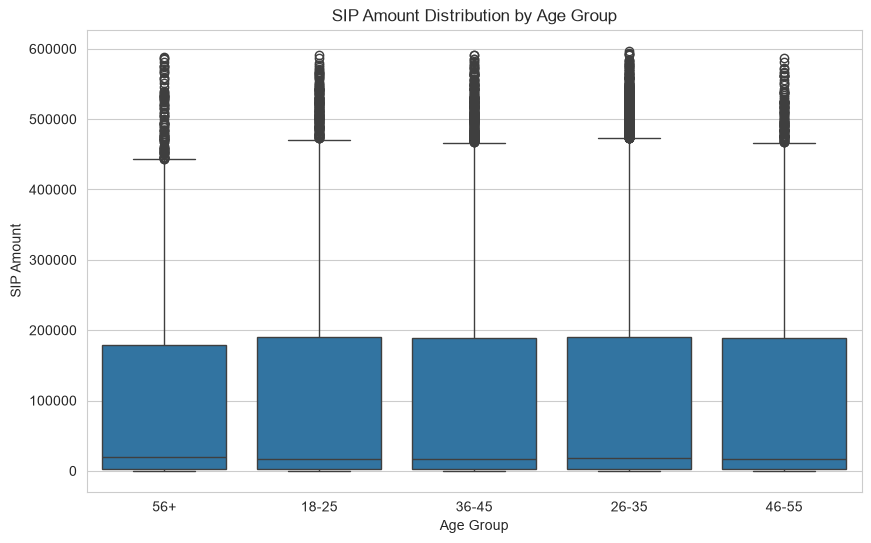

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount")

plt.savefig("../charts/sip_boxplot_agegroup.png", dpi=300)

plt.show()

### Insight

The box plot compares SIP investment patterns across different age groups and highlights the spread and outliers.

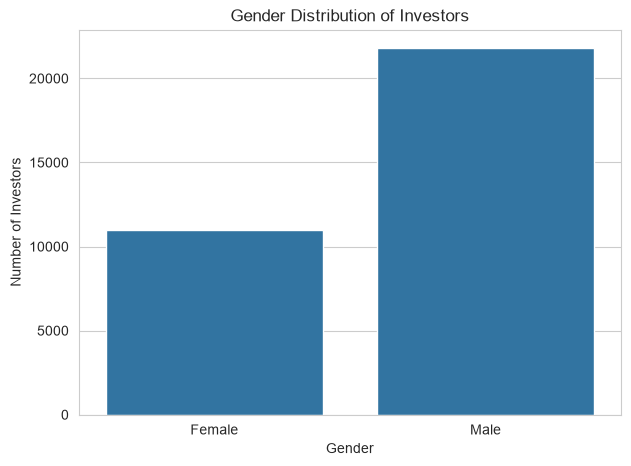

In [198]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig("../charts/gender_distribution.png", dpi=300)

plt.show()

### Insight

The gender distribution provides an overview of male and female participation in mutual fund investments.

# Task6: Geographic distribution 

## Objective
horizontal bar chart of SIP amount by state. T30 vs B30 city tier pie chart.


In [199]:
import pandas as pd

geo = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

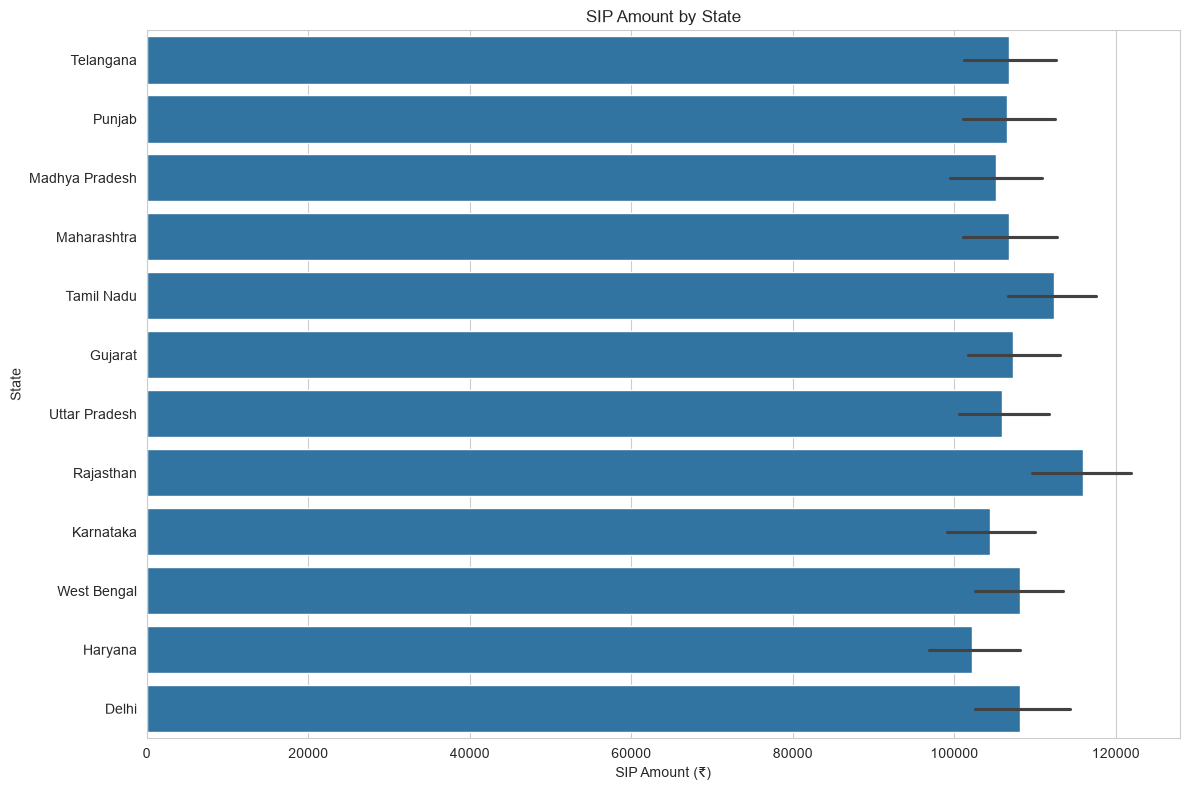

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by SIP amount
geo_sorted = geo.sort_values(by="amount_inr", ascending=False)

plt.figure(figsize=(12,8))

sns.barplot(
    data=geo_sorted,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../charts/sip_amount_by_state.png", dpi=300)

plt.show()

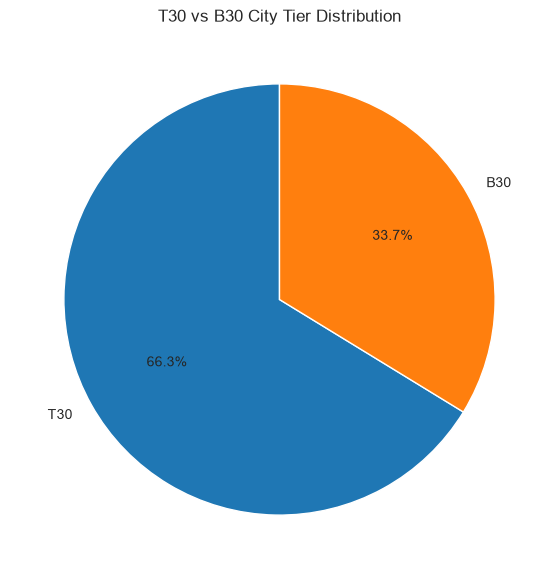

In [201]:
plt.figure(figsize=(7,7))

geo["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")

plt.savefig("../charts/t30_b30_piechart.png", dpi=300)

plt.show()

### Insight

T30 cities account for a larger share of SIP investments, while B30 cities continue to grow, reflecting increasing mutual fund adoption beyond major metropolitan areas.

# Task7: Folio count growth

## Objective
line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.

In [202]:
import pandas as pd

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [203]:
folio["month"] = pd.to_datetime(folio["month"])

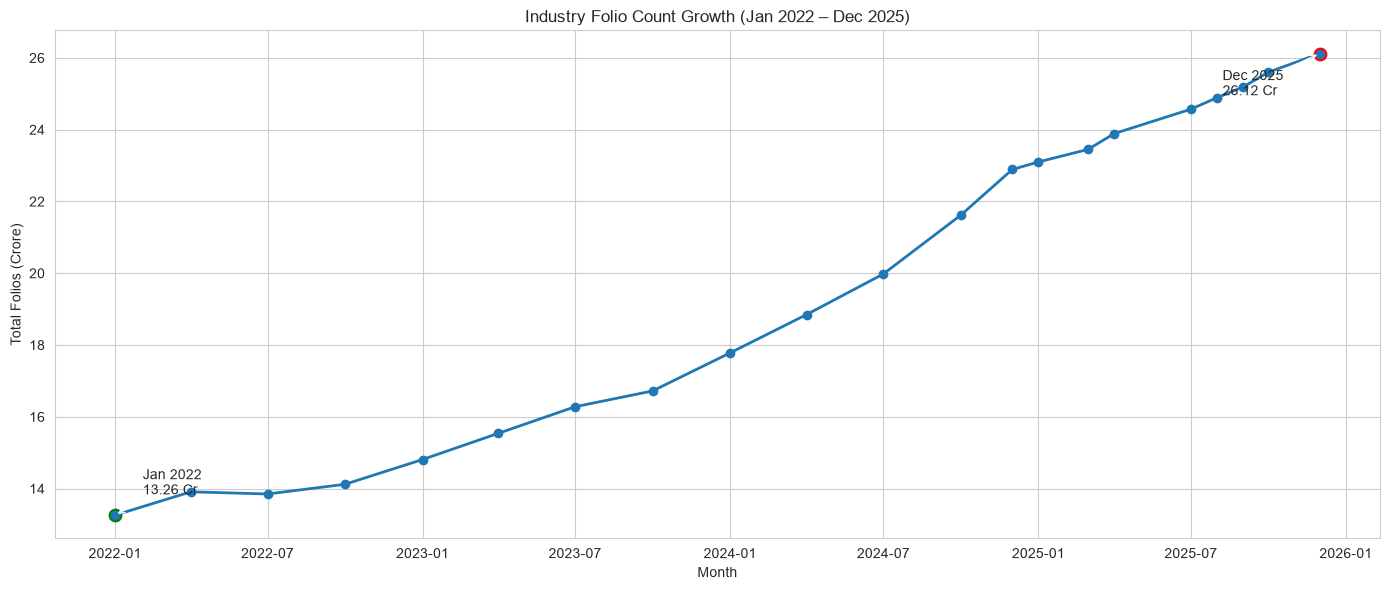

In [204]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Count Growth (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

# Jan 2022
plt.scatter(
    pd.Timestamp("2022-01-01"),
    13.26,
    color="green",
    s=80
)

plt.annotate(
    "Jan 2022\n13.26 Cr",
    xy=(pd.Timestamp("2022-01-01"), 13.26),
    xytext=(20,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Dec 2025
plt.scatter(
    pd.Timestamp("2025-12-01"),
    26.12,
    color="red",
    s=80
)

plt.annotate(
    "Dec 2025\n26.12 Cr",
    xy=(pd.Timestamp("2025-12-01"), 26.12),
    xytext=(-70,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig("../charts/folio_count_growth.png", dpi=300)

plt.show()

### Insight 7: Gender Participation

The total mutual fund folio count increased steadily from **13.26 crore in January 2022** to **26.12 crore in December 2025**, indicating a significant rise in investor participation and sustained growth in the mutual fund industry.

# Task 8: NAV Return Correlation Matrix.

The objective is to calculate the daily return correlation for 10 mutual fund schemes and visualize it using a Seaborn heatmap.

In [205]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [206]:
nav["date"] = pd.to_datetime(nav["date"])

selected_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

In [207]:
pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [208]:
daily_returns = pivot_nav.pct_change().dropna()

corr_matrix = daily_returns.corr()

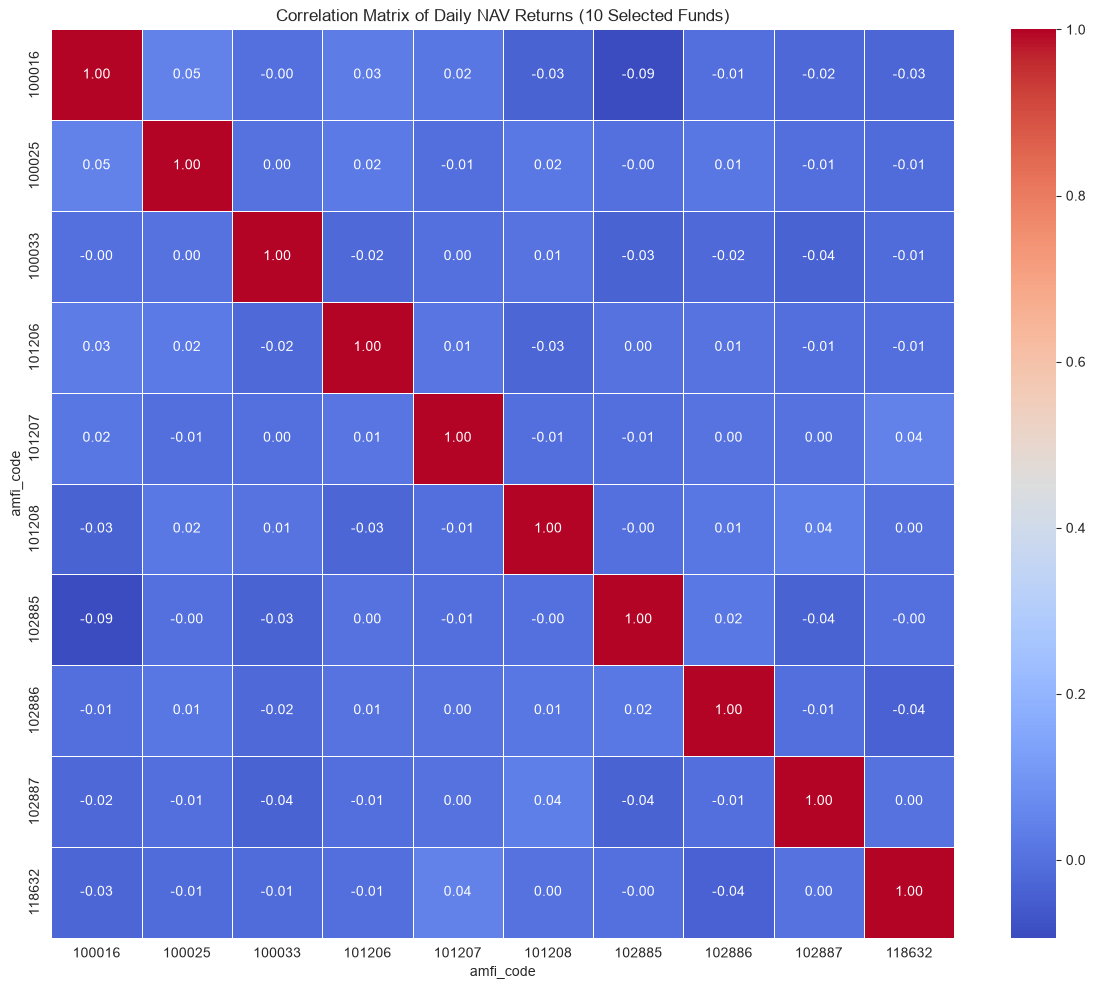

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)")

plt.tight_layout()

plt.savefig("../charts/nav_return_correlation.png", dpi=300)

plt.show()

### Insight

The correlation matrix shows how similarly different mutual fund schemes move over time. Higher positive correlation values indicate similar return patterns, while lower values suggest better diversification opportunities.

# Task 9: Sector Allocation Donut Chart

aggregate sector weights from portfolio_holdings.csv across all equity funds.

In [210]:
import pandas as pd
import plotly.express as px

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [211]:
sector_weight = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

sector_weight.head()

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23


In [212]:
import plotly.express as px

fig = px.pie(
    sector_weight,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()
fig.write_image("../charts/sector_allocation_donut.png")

### Insight

The portfolio is diversified across multiple sectors, with Banking, Utilities, Pharma, and Diversified sectors contributing a significant share of the overall portfolio allocation. This indicates a balanced investment strategy across different industries.

# Conclusion

The exploratory data analysis highlights strong growth in the Indian mutual fund industry between 2022 and 2025. Rising SIP inflows, increasing folio counts, steady AUM growth, and diversified sector allocation indicate growing investor confidence and broader participation. These insights provide a strong foundation for further predictive analysis and investment decision-making.